## HW4 - CORDIC 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

### Result 1 - Find S(N) versus N

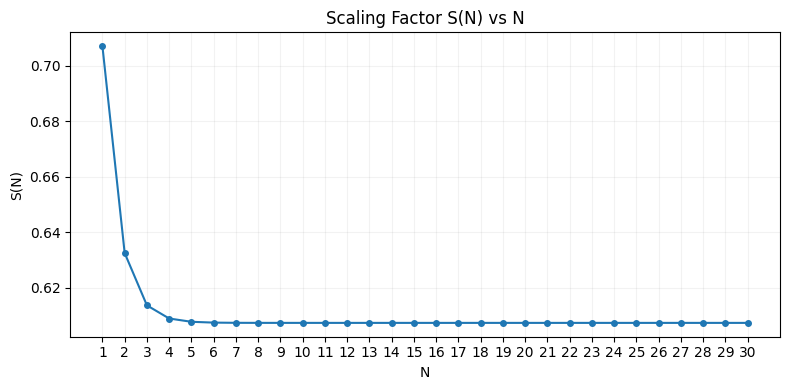

In [11]:
N_max = 30
N_values = np.arange(1, N_max + 1)
S_values = []

for N in N_values:
    product = 1.0
    for i in range(N):
        product *= np.sqrt(1 + 2**(-2*i))
    S_values.append(1.0 / product) # S(N) = 1 / Product

plt.figure(figsize=(8, 4))
plt.plot(N_values, S_values, marker='o', markersize=4)
plt.xlabel('N')
plt.ylabel('S(N)')
plt.title('Scaling Factor S(N) vs N')
plt.xticks(N_values)
plt.grid(True, color='gray', alpha=0.1)
plt.tight_layout()
plt.show()

### Result 2 - Average Absolute Phase Error vs Fractional Wordlength
找 X 跟 Y 應該要用多少定點數位元才能夠滿足門檻

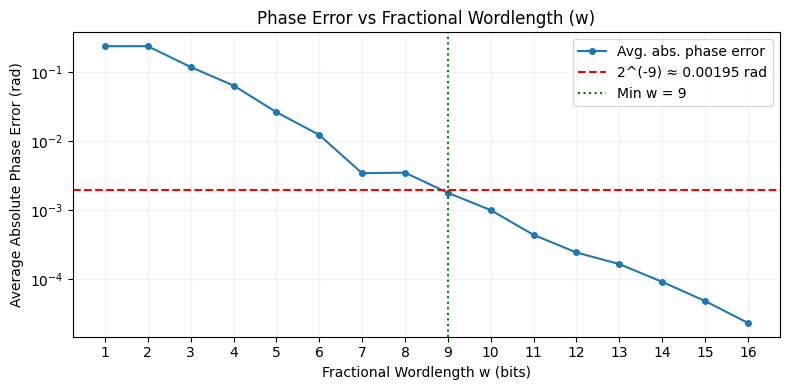

Minimum w satisfying avg error < 2^(-9): w = 9
Total bits per sample: w+2 = 11  (1 sign + 1 integer + 9 fractional)


In [12]:
# Parameters: I=9, beta = mod(9,2)+1 = 2
beta = 2
m_values = np.arange(10)
alpha_m = (4*m_values + beta) / 20 * np.pi

# True inputs (floating-point)
X_true = np.cos(alpha_m)
Y_true = np.sin(alpha_m)

# Reference phase : arctan2 function 方便我們去看象限 
phase_ref = np.arctan2(Y_true, X_true)

# Quantization 給基本角度 LUT 用的 
def quantize(val, w):
    return np.round(val * 2**(w)) / 2**(w)

# CORDIC phase computation (integer shift version, hardware-accurate)
# w_e : fractional wordlength of elementary angle LUT (None = floating-point)
def cordic_phase(X0, Y0, w_xy, N, w_e=None):
    phase_adjust = 0.0

    if X0 < 0: # 代表在第二或是第三象限

        # 如果在第二象限 phase_adjust = pi，第三象限 phase_adjust = -pi
        phase_adjust = np.pi if Y0 >= 0 else -np.pi

        # 全部取負，旋轉 180 度
        X0, Y0 = -X0, -Y0

    # 量化輸入並轉成整數表示 (模擬硬體暫存器)
    Xi = int(np.floor(X0 * 2**w_xy))
    Yi = int(np.floor(Y0 * 2**w_xy))

    theta = 0.0

    for i in range(N):
        mu = -1 if Yi > 0 else 1
        elem_angle = np.arctan(2.0**(-i))
        if w_e is not None:
            elem_angle = quantize(elem_angle, w_e)  # 量化 LUT 基本角度

        # 注意這裡的量化要使用算數右移，因為在後面硬體實作的時候我們會用 Shifter 取代乘法器
        dX = Yi >> i 
        dY = Xi >> i

        # 前面算出來是整數，直接加減就好，不需要再量化了
        Xi_new = Xi - mu * dX
        Yi_new = Yi + mu * dY

        theta = theta - mu * elem_angle

        Xi = Xi_new
        Yi = Yi_new

    return theta + phase_adjust

# Sweep w = 1..16, N = 20
N_iter = 20
w_values = np.arange(1, 17)
avg_errors = []

for w in w_values:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], w, N_iter) - phase_ref[m])
              for m in range(10)]
    avg_errors.append(np.mean(errors))

avg_errors = np.array(avg_errors)

# Find minimum w satisfying error < 2^(-9)
threshold = 2.0**(-9)
valid_w = w_values[avg_errors < threshold]
min_w = int(valid_w[0]) if len(valid_w) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_values, avg_errors, marker='o', markersize=4, label='Avg. abs. phase error')
plt.axhline(threshold, color='r', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_w is not None:
    plt.axvline(min_w, color='g', linestyle=':', label=f'Min w = {min_w}')
plt.xlabel('Fractional Wordlength w (bits)')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title('Phase Error vs Fractional Wordlength (w)')
plt.xticks(w_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

# Integer wordlength analysis
K_N = math.prod(math.sqrt(1 + 2**(-2*i)) for i in range(N_iter))
print(f"Minimum w satisfying avg error < 2^(-9): w = {min_w}")
print(f"Total bits per sample: w+2 = {min_w+2}  (1 sign + 1 integer + {min_w} fractional)")

### Result 3

#### Phase Error vs Number of Micro-rotations
找跌代次數 S 到底要是多少才可以滿足門檻

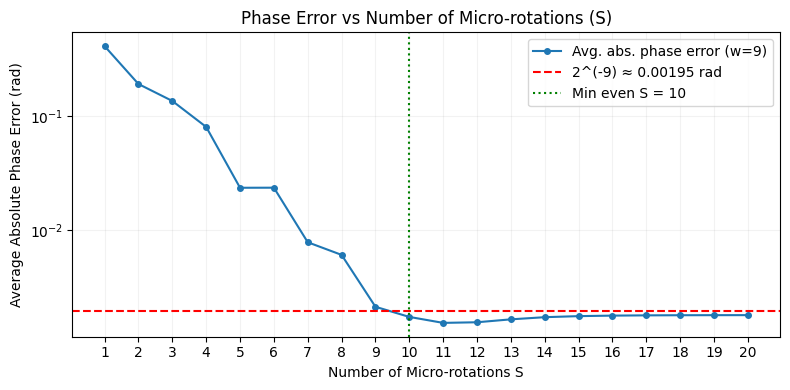

Minimum even S satisfying avg error < 2^(-9): S = 10


In [13]:
S_range = np.arange(1, 21) # sweep S = 1..20 
avg_errors_S = []

for S in S_range:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], min_w, S) - phase_ref[m])
              for m in range(10)]
    avg_errors_S.append(np.mean(errors))

avg_errors_S = np.array(avg_errors_S)

# Find minimum even S satisfying error < 2^(-9)
valid_S = S_range[(avg_errors_S < threshold) & (S_range % 2 == 0)]
min_S = int(valid_S[0]) if len(valid_S) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(S_range, avg_errors_S, marker='o', markersize=4, label=f'Avg. abs. phase error (w={min_w})')
plt.axhline(threshold, color='r', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_S is not None:
    plt.axvline(min_S, color='g', linestyle=':', label=f'Min even S = {min_S}')
plt.xlabel('Number of Micro-rotations S')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title(f'Phase Error vs Number of Micro-rotations (S)')
plt.xticks(S_range)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

print(f"Minimum even S satisfying avg error < 2^(-9): S = {min_S}")

#### Phase Error vs Elementary Angle Wordlength
找 Elementary Angles 的定點數位寬要是多少才能夠滿足門檻

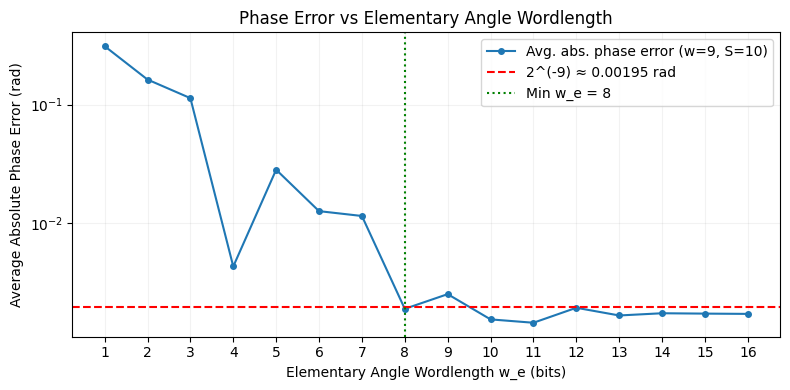

Minimum w_e satisfying avg error < 2^(-9): w_e = 8

Elementary Angles LUT (S=10 stages):
  i          Float           Quantized         Binary (S|II.frac)
-------------------------------------------------------------------
  0      0.7853981634      0.7851562500          000.11001001
  1      0.4636476090      0.4648437500          000.01110111
  2      0.2449786631      0.2460937500          000.00111111
  3      0.1243549945      0.1250000000          000.00100000
  4      0.0624188100      0.0625000000          000.00010000
  5      0.0312398334      0.0312500000          000.00001000
  6      0.0156237286      0.0156250000          000.00000100
  7      0.0078123411      0.0078125000          000.00000010
  8      0.0039062301      0.0039062500          000.00000001
  9      0.0019531225      0.0000000000          000.00000000


In [14]:
w_e_values = np.arange(1, 17) # sweep w_e = 1..16
avg_errors_e = []

for w_e in w_e_values:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], min_w, min_S, w_e=w_e) - phase_ref[m])
              for m in range(10)]
    avg_errors_e.append(np.mean(errors))

avg_errors_e = np.array(avg_errors_e)

# Find minimum w_e satisfying error < 2^(-9)
valid_w_e = w_e_values[avg_errors_e < threshold]
min_w_e = int(valid_w_e[0]) if len(valid_w_e) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_e_values, avg_errors_e, marker='o', markersize=4,
             label=f'Avg. abs. phase error (w={min_w}, S={min_S})')
plt.axhline(threshold, color='r', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_w_e is not None:
    plt.axvline(min_w_e, color='g', linestyle=':', label=f'Min w_e = {min_w_e}')
plt.xlabel('Elementary Angle Wordlength w_e (bits)')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title(f'Phase Error vs Elementary Angle Wordlength')
plt.xticks(w_e_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

print(f"Minimum w_e satisfying avg error < 2^(-9): w_e = {min_w_e}")

# Table of elementary angles (LUT content)
# Format: 1S + 2I + w_e F  (sign | integer integer . fractional bits)
print(f"\nElementary Angles LUT (S={min_S} stages):")
print(f"{'i':>3} {'Float':>14}  {'Quantized':>18} {'Binary (S|II.frac)':>26}")
print("-" * 67)
for i in range(min_S):
    angle_f = np.arctan(2.0**(-i))
    angle_q = quantize(angle_f, min_w_e)
    int_bits = int(np.round(angle_q * 2**min_w_e))
    binary_str = '000.' + format(int_bits, f'0{min_w_e}b')  # sign=0, integer=00
    print(f"{i:>3}  {angle_f:>16.10f}  {angle_q:>16.10f}  {binary_str:>20}")

### Result 5 - CSD Representation of Scaling Factor S(N)
要把 Scaling Factor 轉換成 CSD 表示法

S(10) = 0.6072533211


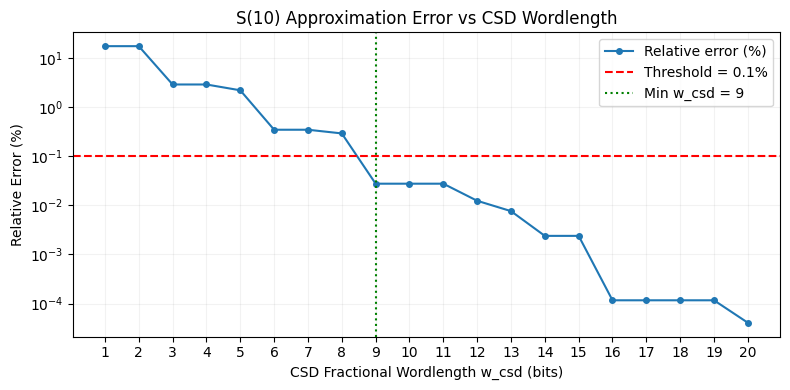


Minimum w_csd satisfying error < 0.1%: w_csd = 9
S_true  = 0.6072533211
S_csd   = 0.6074218750
Error   = 0.0278%

Shift-and-add block (S = 0.607421875):
   Shift   Digit  Operation
  -----------------------------------
       1      +1  + (X >> 1)
       3      +1  + (X >> 3)
       6      -1  - (X >> 6)
       9      -1  - (X >> 9)

Non-zero CSD digits : 4
Adders required     : 3


In [15]:
# S(N) for N = 10
N_mag = 10
S_true = 1.0 / math.prod(math.sqrt(1 + 2**(-2*i)) for i in range(N_mag))
print(f"S({N_mag}) = {S_true:.10f}")

# CSD conversion (Non-Adjacent Form)
def to_csd(value, n_frac_bits):
    # 先把浮點數直接截斷成定點數
    n = int(np.round(value * 2**n_frac_bits))
    digits = {}
    pos = -n_frac_bits                      # 記錄當前 bit 對應的位置，一開始為最後
    while n != 0:
        if n & 1:                           # 檢查最低位是否為 1 -> n is odd
            d = -1 if (n & 3) == 3 else 1   # 看最後兩位來決定 d 是 +1 (else) 還是 -1 (11)
            digits[pos] = d                 # 存入 digits 中
            n -= d                          # 消掉
        n >>= 1                             # 往下一位移動
        pos += 1                            # 位移後 pos 也要跟著增加

    # 把做完 CSD 轉換後的 digits 加總回來得到近似值，就可以用這個近似值去看誤差了
    csd_val = sum(d * 2.0**p for p, d in digits.items())  # 2.0 to allow negative exponents
    return csd_val, digits

threshold_csd = 0.1 
w_csd_values = np.arange(1, 21)
errors_csd = []

for w_csd in w_csd_values: # 找出 csd 的最小位元寬度
    S_csd, _ = to_csd(S_true, w_csd)
    errors_csd.append(abs(S_true - S_csd) / S_true * 100)

errors_csd = np.array(errors_csd)

# Find minimum w_csd satisfying error < 0.1%
valid_csd = w_csd_values[errors_csd < threshold_csd]
min_w_csd = int(valid_csd[0]) if len(valid_csd) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_csd_values, errors_csd, marker='o', markersize=4, label='Relative error (%)')
plt.axhline(threshold_csd, color='r', linestyle='--', label=f'Threshold = 0.1%')
if min_w_csd is not None:
    plt.axvline(min_w_csd, color='g', linestyle=':', label=f'Min w_csd = {min_w_csd}')
plt.xlabel('CSD Fractional Wordlength w_csd (bits)')
plt.ylabel('Relative Error (%)')
plt.title(f'S({N_mag}) Approximation Error vs CSD Wordlength')
plt.xticks(w_csd_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

# CSD representation and shift-and-add analysis
S_csd_final, digits_final = to_csd(S_true, min_w_csd)
nonzero = {p: d for p, d in digits_final.items() if d != 0}
n_nonzero = len(nonzero)

print(f"\nMinimum w_csd satisfying error < 0.1%: w_csd = {min_w_csd}")
print(f"S_true  = {S_true:.10f}")
print(f"S_csd   = {S_csd_final:.10f}")
print(f"Error   = {abs(S_true - S_csd_final) / S_true * 100:.4f}%")
print(f"\nShift-and-add block (S = {S_csd_final}):")
print(f"  {'Shift':>6}  {'Digit':>6}  Operation")
print("  " + "-" * 35)
for p in sorted(nonzero.keys(), reverse=True):
    d = nonzero[p]
    shift = -p   # bit position -k → right shift by k
    sign = "+" if d == 1 else "-"
    print(f"  {shift:>6}  {d:>+6}  {sign} (X >> {shift})")
print(f"\nNon-zero CSD digits : {n_nonzero}")
print(f"Adders required     : {n_nonzero - 1}")


### Result 6 - Initial Stage Design
生成 PI 的量化定點數

In [16]:
w_phase = min_w_e  # use same fractional width as elementary angle LUT

pi_float = np.pi
pi_fixed  = int(np.round( pi_float * 2**w_phase))
neg_pi_fixed = -pi_fixed                          

pi_quantized     =  pi_fixed  / 2**w_phase
neg_pi_quantized = neg_pi_fixed / 2**w_phase

# Binary representation: 1S + 2I + w_phase F
def to_fixed_bin(int_val, w_frac, n_int=2):
    """Convert signed integer (scaled by 2^w_frac) to binary string: S II.frac"""
    total_mag_bits = n_int + w_frac
    if int_val >= 0:
        sign_bit = '0'
        bits = format(int_val, f'0{total_mag_bits}b')
    else:
        # two's complement
        sign_bit = '1'
        bits = format((1 << total_mag_bits) + int_val, f'0{total_mag_bits}b')
    return sign_bit + '_' + bits[:n_int] + '.' + bits[n_int:]

pi_bin     = to_fixed_bin( pi_fixed, w_phase)
neg_pi_bin = to_fixed_bin(neg_pi_fixed, w_phase)

print(f"Phase Adjust constants  (1S + 2I + {w_phase}F,  total {w_phase+3} bits)")
print(f"  +π  float = {pi_float:.10f}")
print(f"  +π  fixed = {pi_quantized:.10f}  (integer = {pi_fixed:5d})  binary = {pi_bin}")
print(f"  -π  float = {-pi_float:.10f}")
print(f"  -π  fixed = {neg_pi_quantized:.10f}  (integer = {neg_pi_fixed:5d})  binary = {neg_pi_bin}")
print(f"\n  Quantization error: {abs(pi_float - pi_quantized):.6e} rad")

Phase Adjust constants  (1S + 2I + 8F,  total 11 bits)
  +π  float = 3.1415926536
  +π  fixed = 3.1406250000  (integer =   804)  binary = 0_11.00100100
  -π  float = -3.1415926536
  -π  fixed = -3.1406250000  (integer =  -804)  binary = 1_00.11011100

  Quantization error: 9.676536e-04 rad


### Result 6 - Test Data Generation
產生 m = 0~9 的 X、Y 測試資料，格式為 **1S 1I 9F（11-bit two's complement）**

In [17]:
# 整理一下定點數位寬的結果，方便後續分析
print(f"\nSummary of Wordlengths:")
print(f"X and Y wordlength       = {min_w + 2} bits  (1 sign + 1 integer + {min_w} fractional)")
print(f"Elementary angle LUT w_e = {min_w_e} bits")
print(f"CSD scaling factor w_csd = {min_w_csd} bits  (N={N_mag})")

# Parameters 
beta      = 2          # mod(9, 2) + 1
W_XY      = 9          # fractional bits  (1S 1I 9F → 11 bits total)
TOTAL_W   = 1 + 1 + W_XY   # 11 bits
m_values  = np.arange(10)

alpha_m = (4 * m_values + beta) / 20 * np.pi
X_float = np.cos(alpha_m)
Y_float = np.sin(alpha_m)

# Quantisation: floor to 1S 1I 9F two's complement 
def to_twos_complement_bin(val, w_frac, total_bits):
    """
    Quantise float val to fixed-point with w_frac fractional bits,
    then return total_bits-wide two's complement binary string.
    Uses floor (arithmetic right-shift compatible, matches hardware).
    """
    scaled = int(np.floor(val * 2**w_frac))          # floor truncation
    if scaled < 0:
        scaled = (1 << total_bits) + scaled           # two's complement wrap
    return format(scaled & ((1 << total_bits) - 1), f'0{total_bits}b')

X_bin = [to_twos_complement_bin(x, W_XY, TOTAL_W) for x in X_float]
Y_bin = [to_twos_complement_bin(y, W_XY, TOTAL_W) for y in Y_float]

# Write .dat files
out_dir = os.path.join(os.path.dirname(os.path.abspath("HW4.ipynb")),
                       "00_TESTBED", "src")
os.makedirs(out_dir, exist_ok=True)

with open(os.path.join(out_dir, "InX.dat"), "w") as f:
    f.write("\n".join(X_bin) + "\n")

with open(os.path.join(out_dir, "InY.dat"), "w") as f:
    f.write("\n".join(Y_bin) + "\n")

print("\nFiles written successfully.")


Summary of Wordlengths:
X and Y wordlength       = 11 bits  (1 sign + 1 integer + 9 fractional)
Elementary angle LUT w_e = 8 bits
CSD scaling factor w_csd = 9 bits  (N=10)

Files written successfully.


### Result 7 - Hardware Implementation Error Analysis
讀取硬體模擬輸出 `OutTheta.dat`（1S 2I 8F），與浮點 arctan2 參考值比較，驗證誤差 < 2⁻⁹ rad。

 m   alpha/pi    arctan2 ref    HW output   |error| (rad)
--------------------------------------------------------
 0   0.100000     0.31415927   0.31250000        1.66e-03
 1   0.300000     0.94247780   0.94531250        2.83e-03
 2   0.500000     1.57079633   1.57031250        4.84e-04
 3   0.700000     2.19911486   2.19531250        3.80e-03
 4   0.900000     2.82743339   2.82812500        6.92e-04
 5   1.100000    -2.82743339  -2.82812500        6.92e-04
 6   1.300000    -2.19911486  -2.19531250        3.80e-03
 7   1.500000    -1.57079633  -1.57031250        4.84e-04
 8   1.700000    -0.94247780  -0.94531250        2.83e-03
 9   1.900000    -0.31415927  -0.31250000        1.66e-03

Output resolution (1 LSB = 2^-8) : 3.9062e-03 rad
Average absolute error            : 1.8944e-03 rad
Threshold 2^-9                    : 1.9531e-03 rad
Average error < 2^-9 ?            : PASS


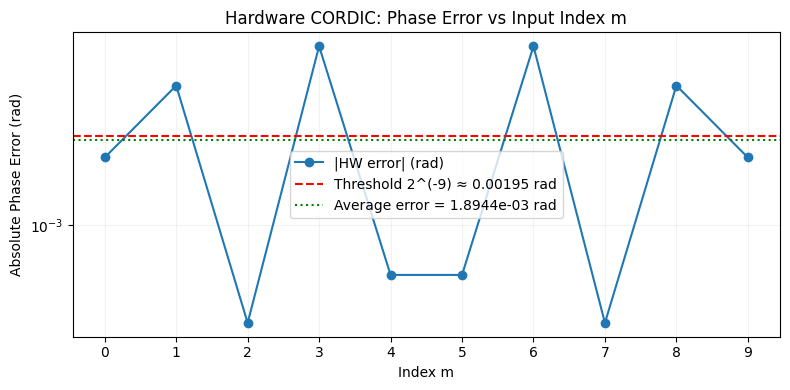

In [18]:
# ── Parameters ────────────────────────────────────────────────────────────────
W_THETA  = 8    # fractional bits of OutTheta (1S 2I 8F)
TOTAL_TW = 11   # total bits

# ── Read hardware output ───────────────────────────────────────────────────────
hw_dat = os.path.join(os.path.dirname(os.path.abspath("HW4.ipynb")),
                      "00_TESTBED", "src", "OutTheta.dat")

with open(hw_dat) as f:
    lines = [l.strip() for l in f if l.strip()]

def twos_complement_to_float(bin_str, w_frac, total_bits):
    """11-bit two's complement binary string → signed float (1S 2I 8F)."""
    val = int(bin_str, 2)
    if val >= (1 << (total_bits - 1)):   # MSB = 1 → negative
        val -= (1 << total_bits)
    return val / (2 ** w_frac)

hw_theta = np.array([twos_complement_to_float(l, W_THETA, TOTAL_TW) for l in lines])

# ── Reference: floating-point arctan2 ────────────────────────────────────────
# phase_ref and alpha_m are already defined in earlier cells
errors = np.abs(hw_theta - phase_ref)
avg_error = np.mean(errors)

# ── Print table ───────────────────────────────────────────────────────────────
# Note: requirement is AVERAGE error < 2^-9, not every individual error.
#       Individual errors can exceed 2^-9 because output resolution = 2^-8 > 2^-9.
print(f"{'m':>2}  {'alpha/pi':>9}  {'arctan2 ref':>13}  {'HW output':>11}  {'|error| (rad)':>14}")
print("-" * 56)
for m in range(10):
    print(f"{m:>2}  {alpha_m[m]/np.pi:>9.6f}  {phase_ref[m]:>13.8f}  {hw_theta[m]:>11.8f}  {errors[m]:>14.2e}")

print(f"\nOutput resolution (1 LSB = 2^-8) : {2**-8:.4e} rad")
print(f"Average absolute error            : {avg_error:.4e} rad")
print(f"Threshold 2^-9                    : {threshold:.4e} rad")
print(f"Average error < 2^-9 ?            : {'PASS' if avg_error < threshold else 'FAIL'}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.semilogy(range(10), errors, marker='o', markersize=6, label='|HW error| (rad)')
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold 2^(-9) ≈ {threshold:.5f} rad')
plt.axhline(avg_error, color='g', linestyle=':', label=f'Average error = {avg_error:.4e} rad')
plt.xlabel('Index m')
plt.ylabel('Absolute Phase Error (rad)')
plt.title('Hardware CORDIC: Phase Error vs Input Index m')
plt.xticks(range(10))
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()